In [6]:
from decluttering.src.divergence_utils import divergence

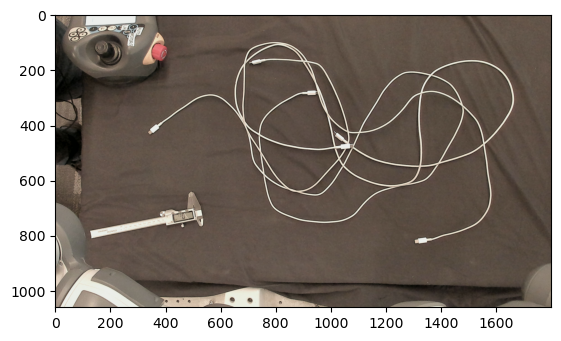

In [7]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# im_frame2 = Image.open("/home/justinyu/vsumedh/data/raw_images/parallel-20240730-152135.png")
im_frame2 = Image.open("/home/justinyu/vsumedh/data/raw_images/parallel-20240711-132710.png")
# im_frame2 = Image.open("/home/justinyu/vsumedh/data/raw_images/parallel-20240711-124446.png")

np_frame2 = np.array(im_frame2)
np_frame2 = np_frame2[:, 0:1800,:]
img = np_frame2
plt.imshow(img)

(1060, 1800, 3)


Endpoint detection took 0.6588394641876221 seconds


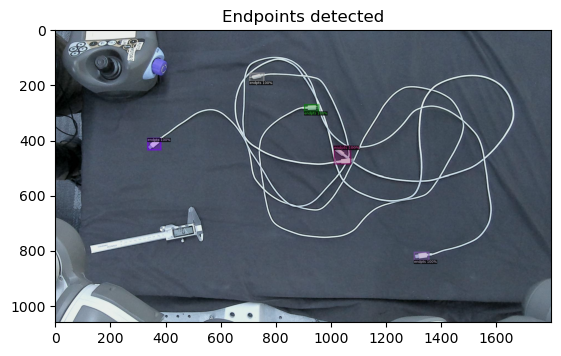

(1060, 1800, 3)
[[ 174  732]
 [ 821 1330]
 [ 415  359]
 [ 455 1042]
 [ 285  930]]


<Figure size 640x480 with 0 Axes>

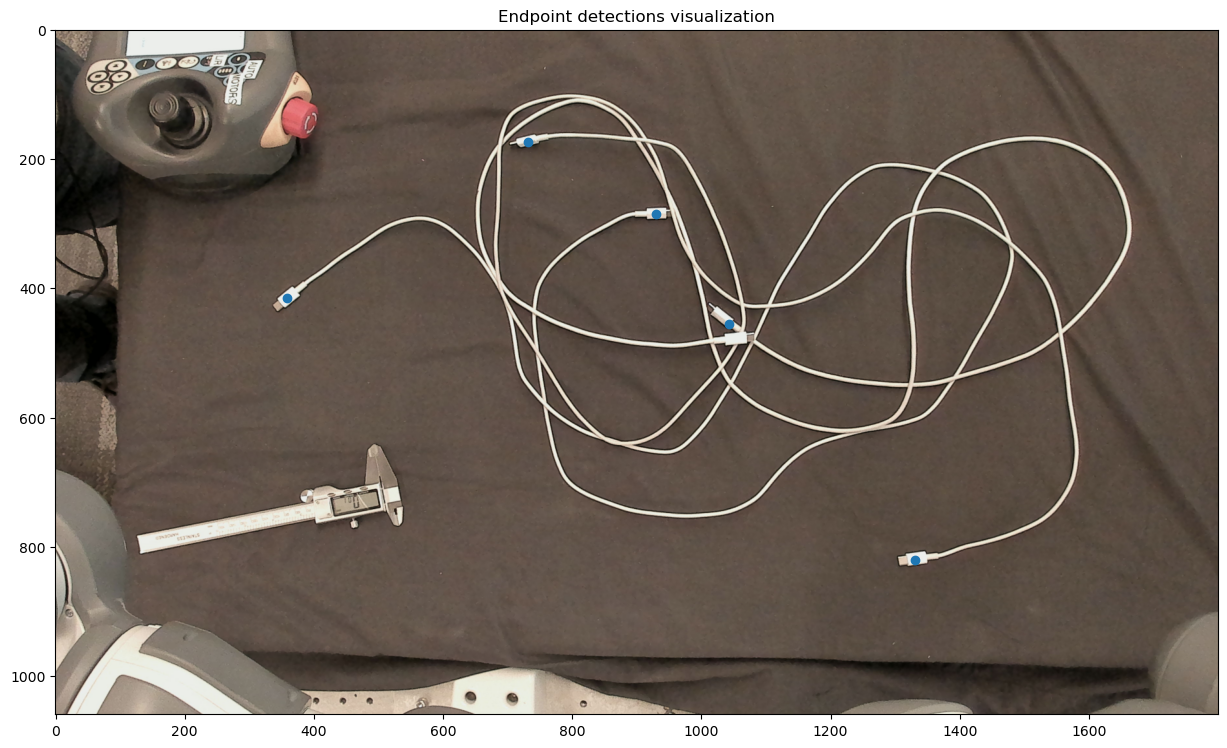

In [8]:
from decluttering.data.detectron2_repo import analysis as loop_detectron
import numpy as np 
import time

def get_endpoints(img):
    endpoint_start = time.time()
    endpoint_boxes, out_viz = loop_detectron.predict(img, thresh=0.99, endpoints=True)
    endpoint_end = time.time()
    print("Endpoint detection took {} seconds".format(endpoint_end - endpoint_start))
    plt.clf()
    plt.imshow(out_viz)
    plt.title("Endpoints detected")
    plt.show()
    plt.imsave("/home/justinyu/multicable-decluttering/misc_images/endpoints_detected.png", out_viz)
    print(out_viz.shape)

    endpoints = []
    for i, box in enumerate(endpoint_boxes):
        xmin, ymin, xmax, ymax = box
        x = (xmin + xmax)/2
        y = (ymin + ymax)/2
        endpoints.append([y, x])   
    endpoints = np.array(endpoints).astype(np.int32)
    print(endpoints)

    plt.clf()
    plt.figure(figsize=(15,18))
    plt.title("Endpoint detections visualization")
    plt.imshow(img)
    if len(endpoints) > 0:
        plt.scatter(endpoints[:, 1], endpoints[:, 0])
    plt.show()
    return endpoints

print(img.shape)
endpts = get_endpoints(img)

Autoregressive Tracer Using GPU


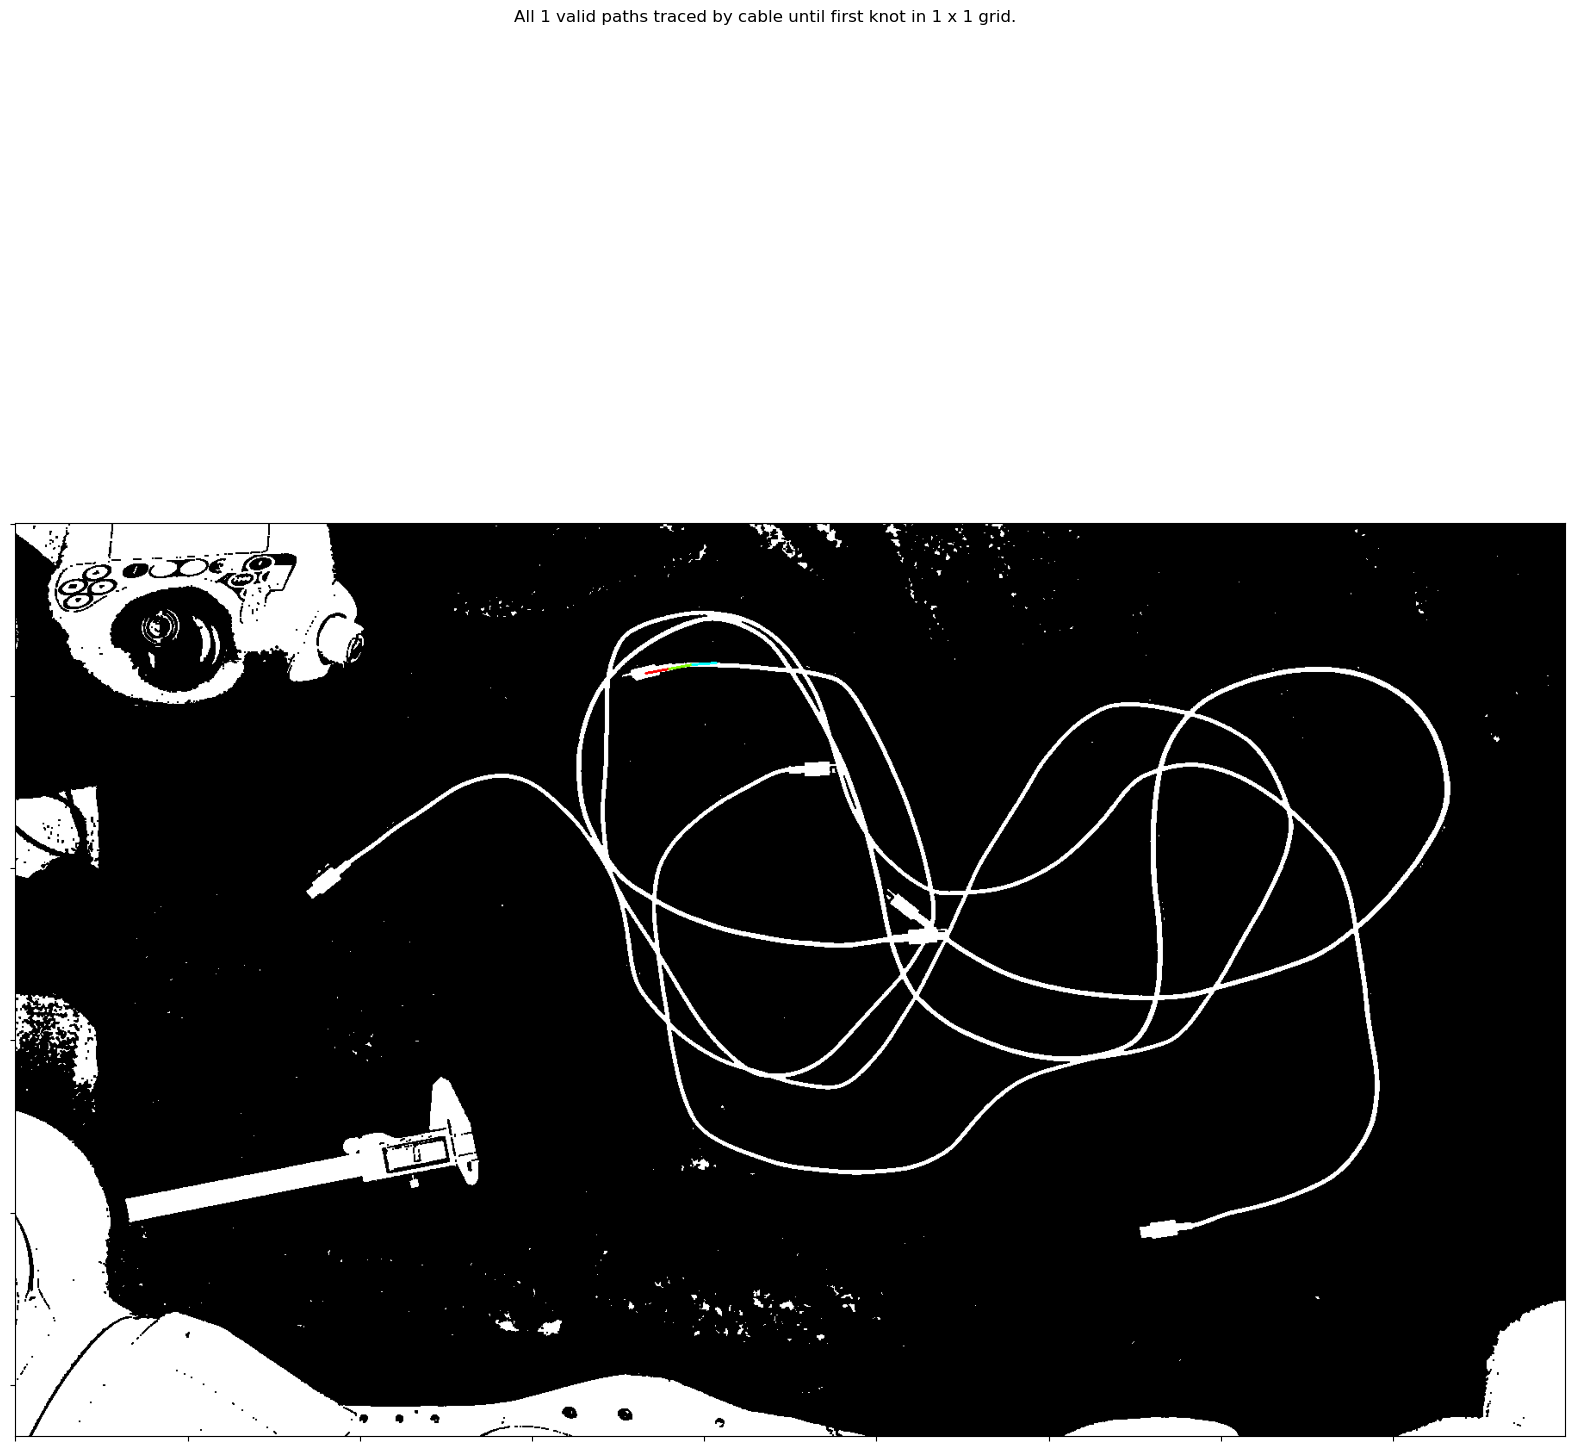

Autoregressive Tracer Using GPU


Beginning trace with 4 start points
Elapsed time for tracing:  1.0452353954315186
Autoregressive Tracer Using GPU


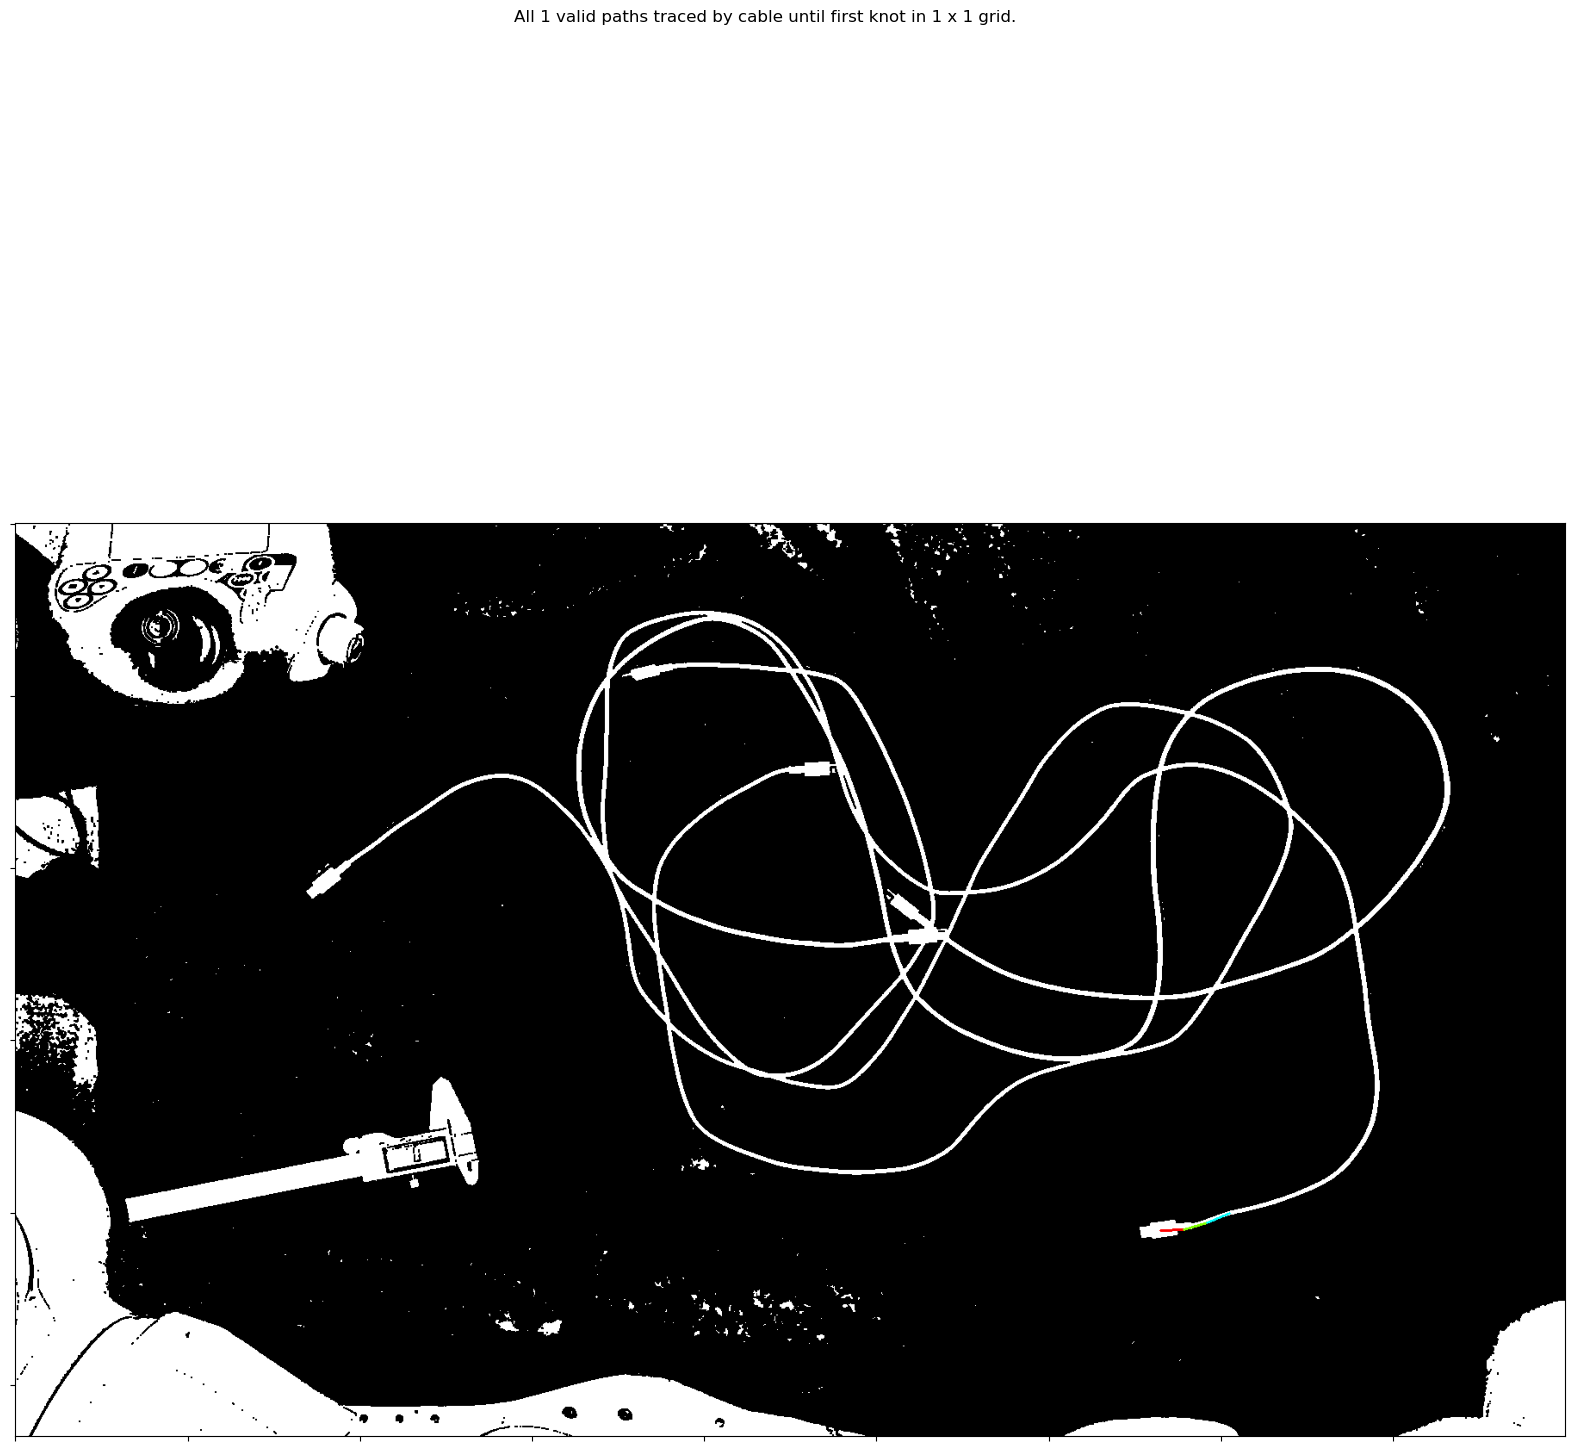

Autoregressive Tracer Using GPU
Beginning trace with 4 start points
Elapsed time for tracing:  2.0458974838256836
Autoregressive Tracer Using GPU


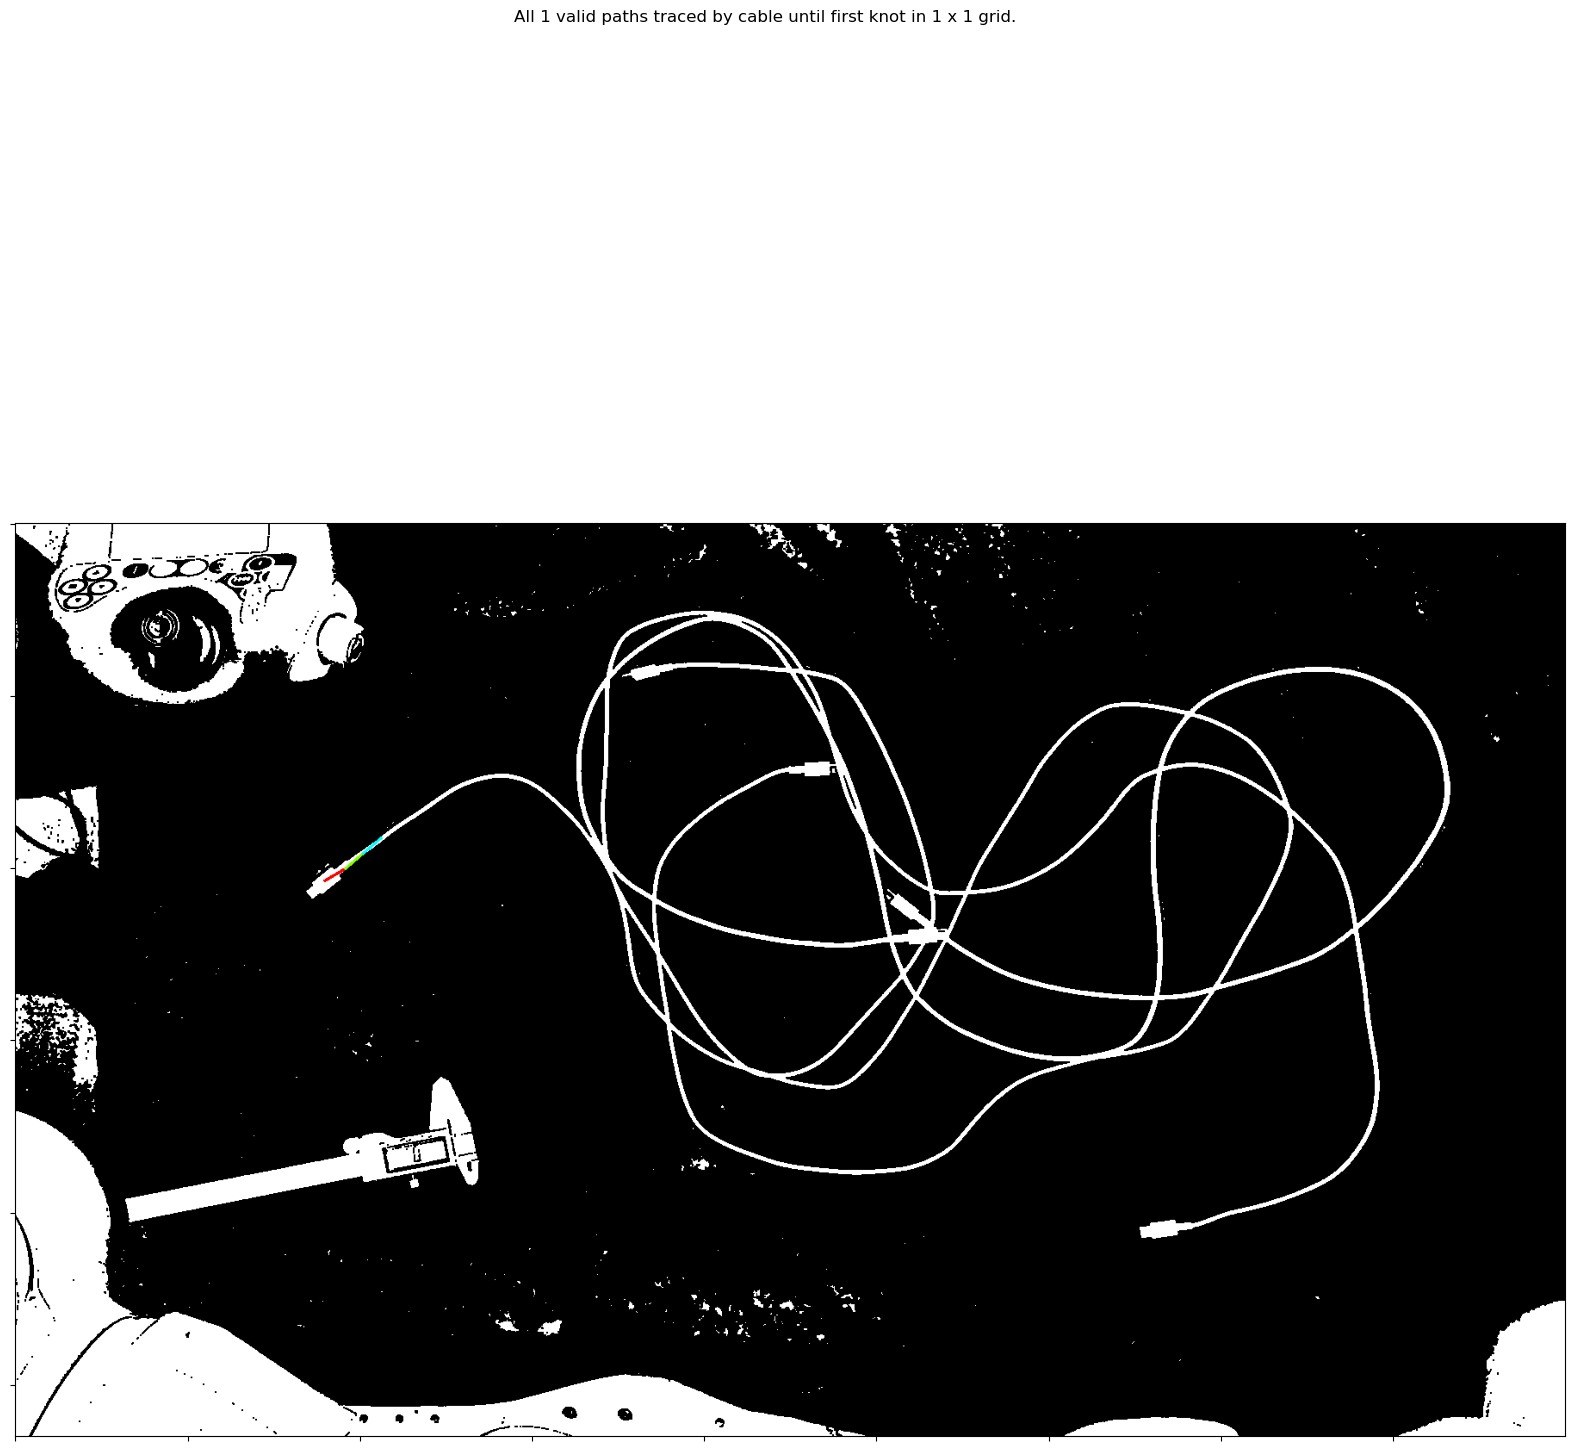

Autoregressive Tracer Using GPU
Beginning trace with 4 start points
Elapsed time for tracing:  0.8765711784362793
Autoregressive Tracer Using GPU


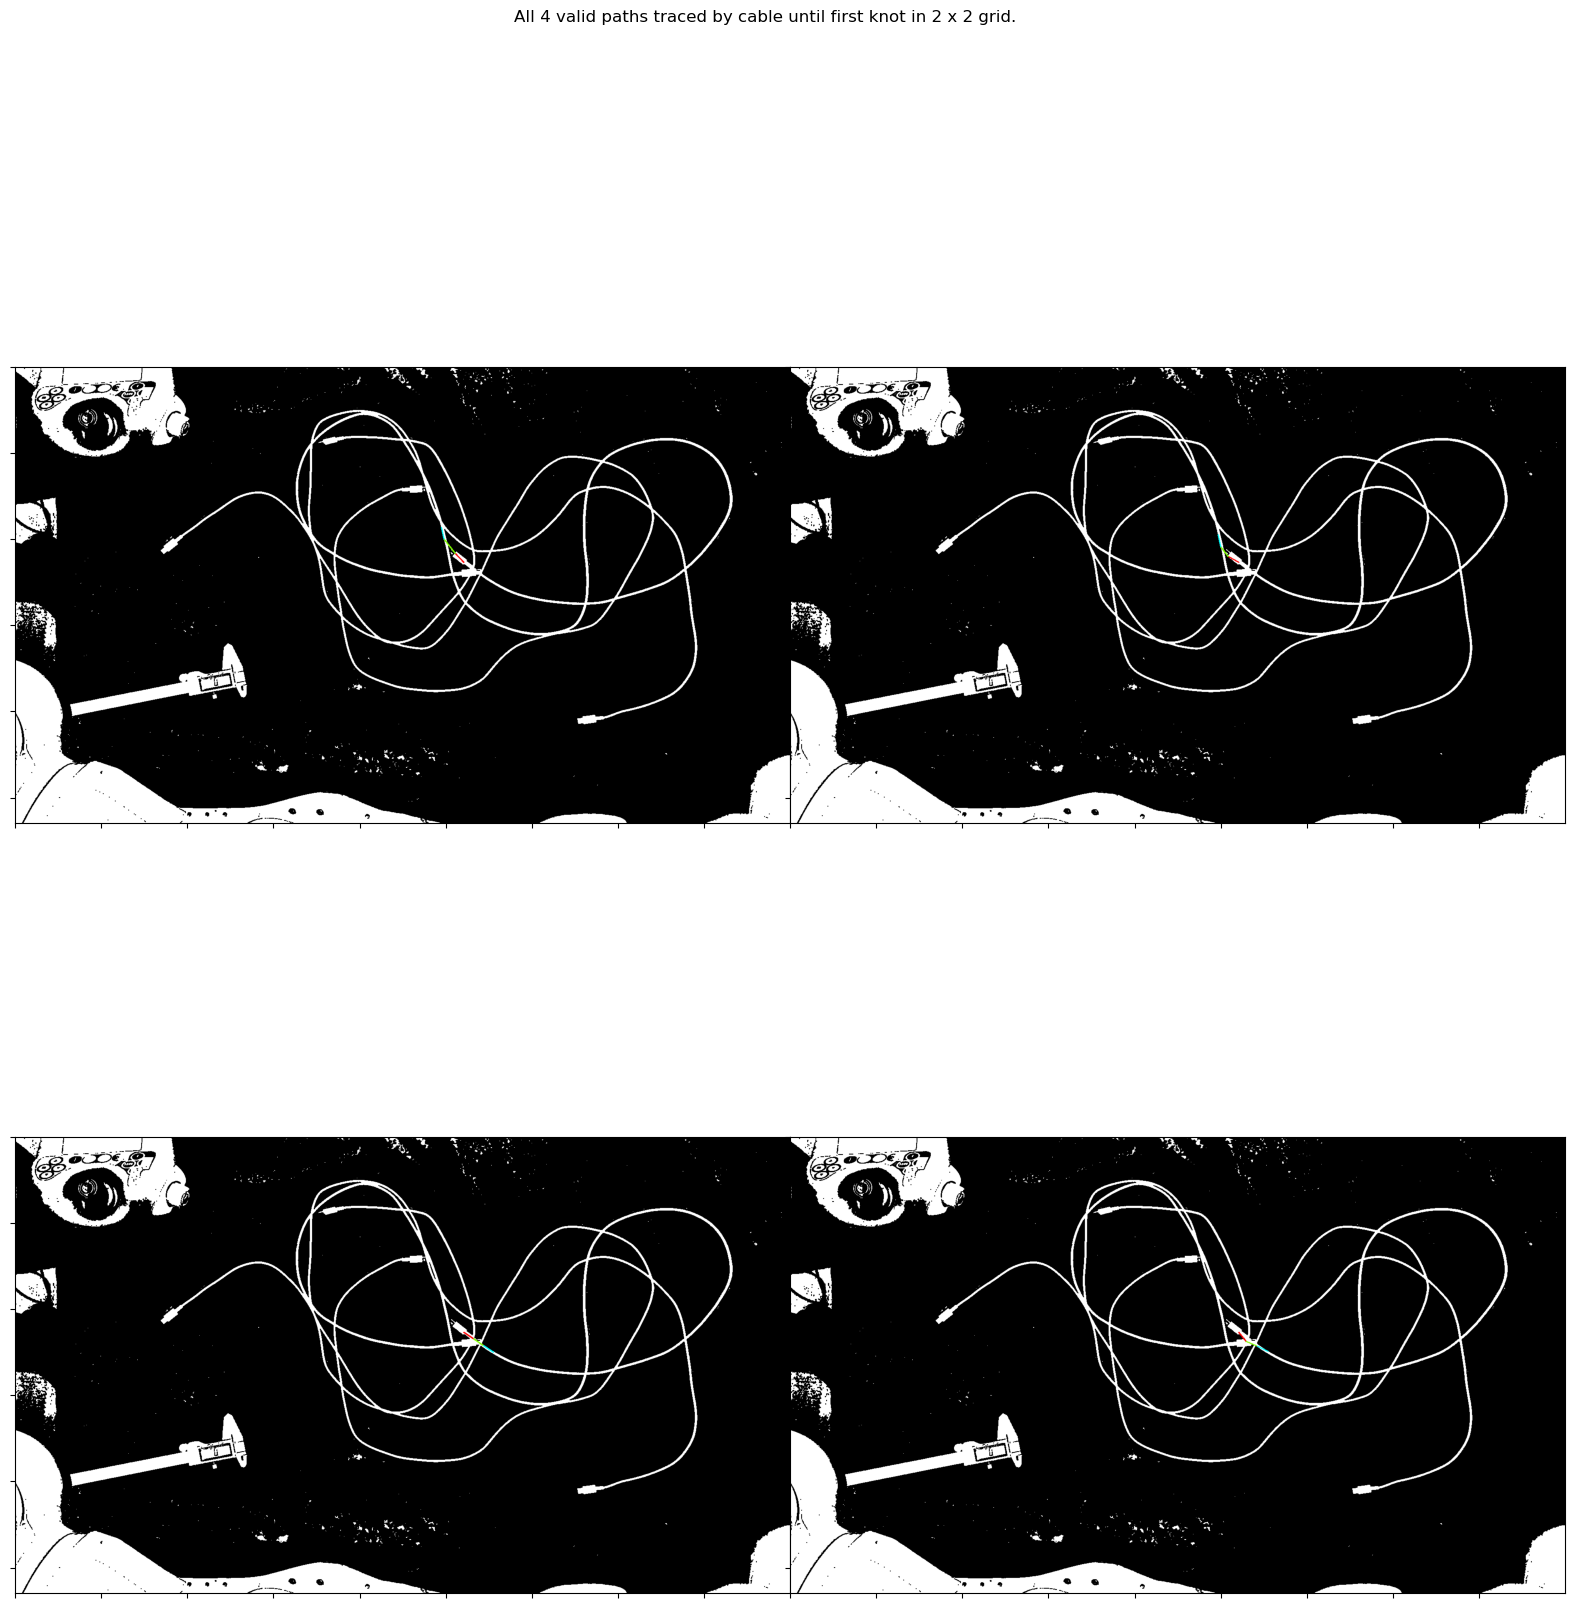

Autoregressive Tracer Using GPU
Beginning trace with 4 start points
Elapsed time for tracing:  0.8846340179443359
Autoregressive Tracer Using GPU


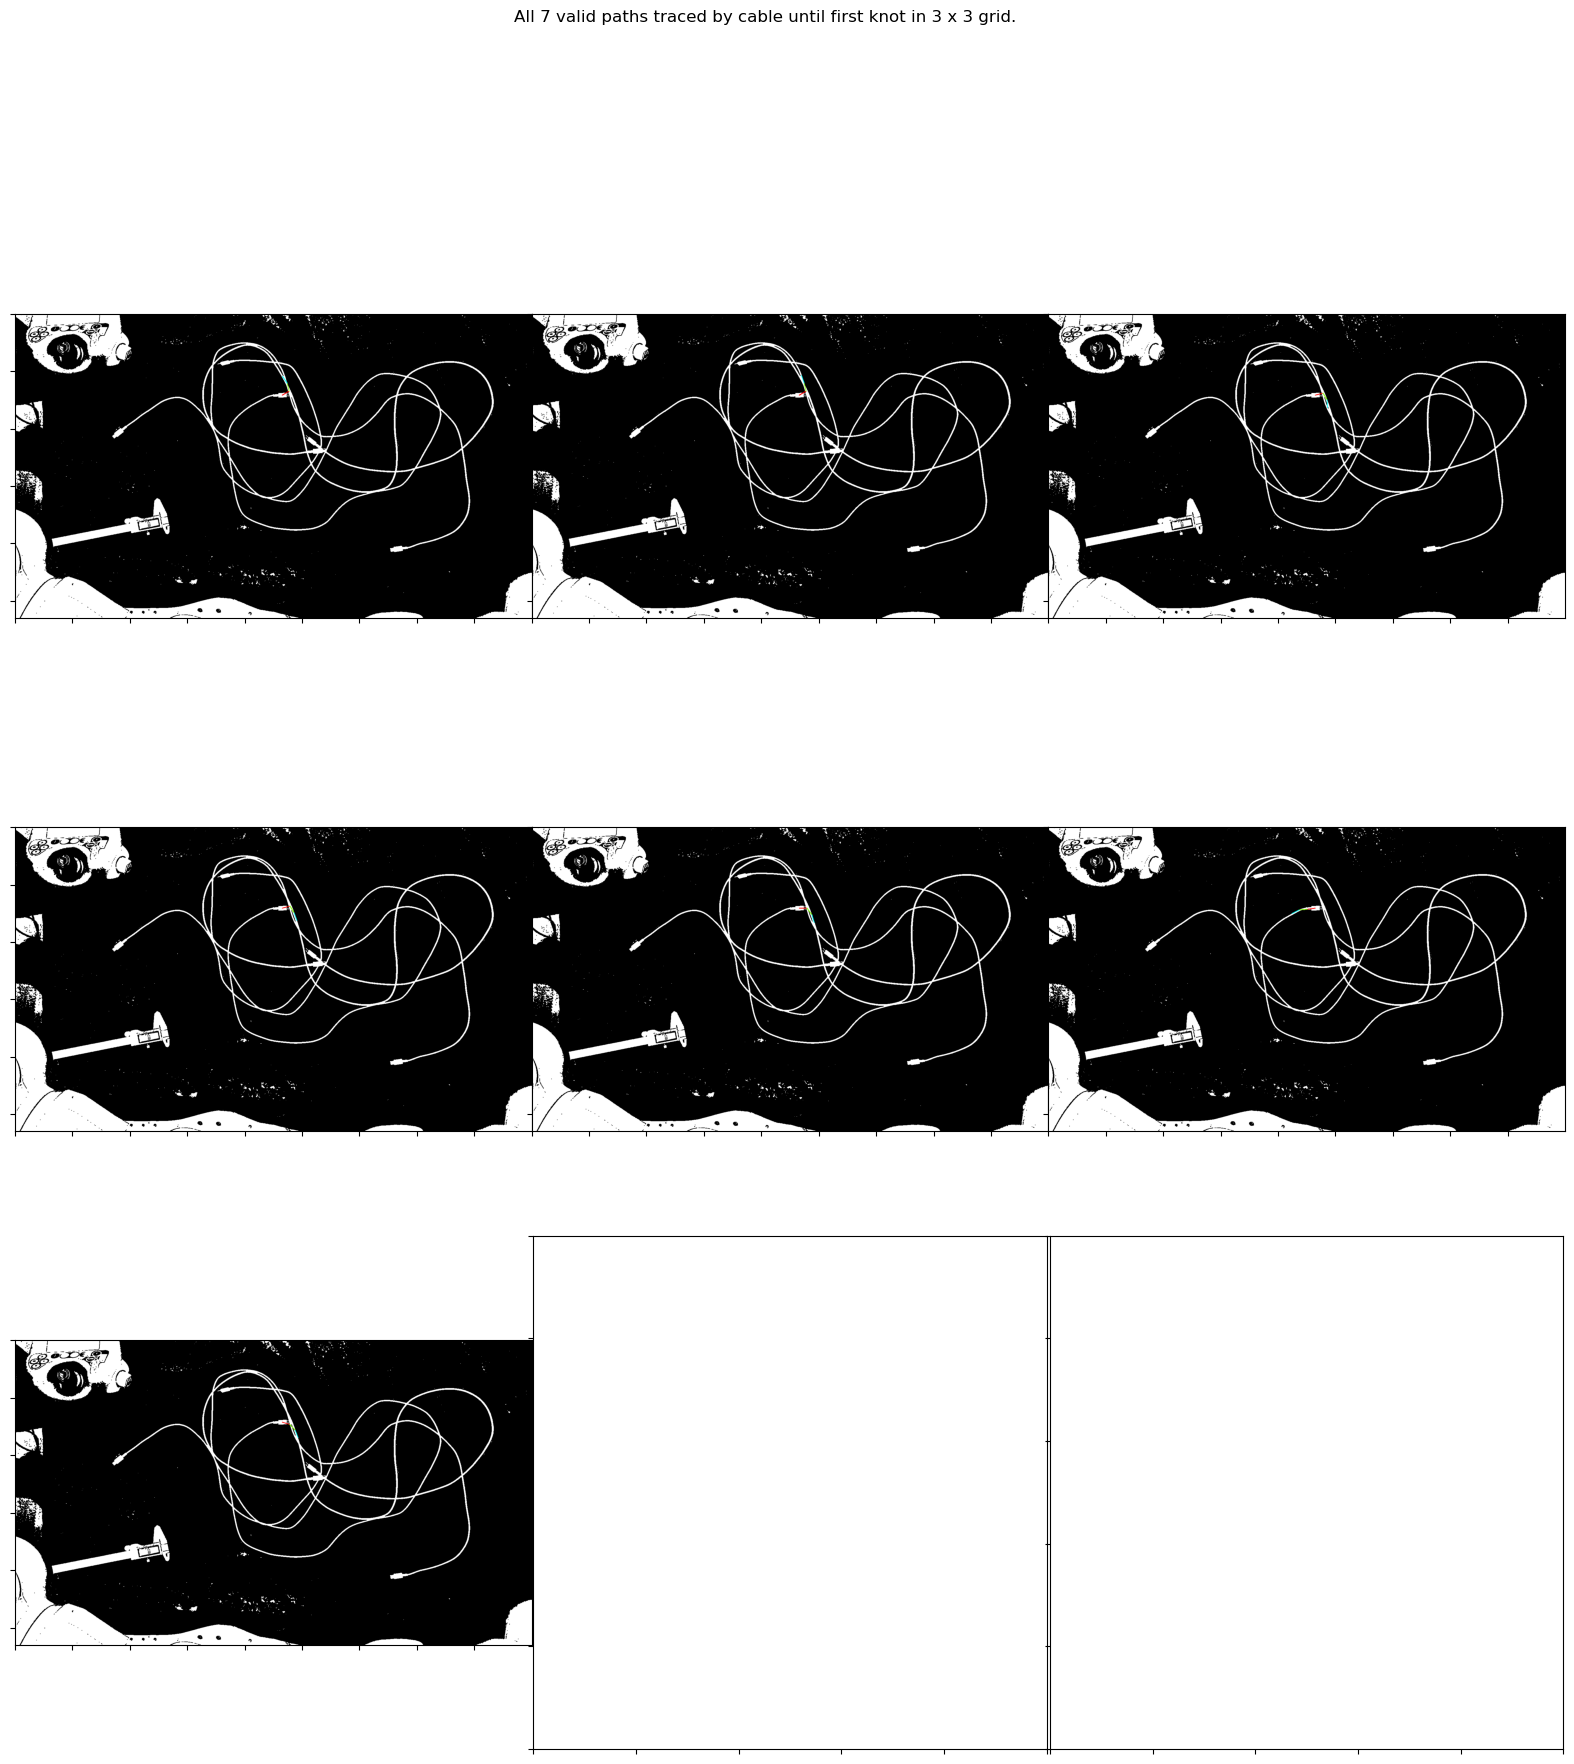

Autoregressive Tracer Using GPU
Beginning trace with 4 start points
Elapsed time for tracing:  1.8840525150299072
RETURN VAL = [array([[ 742.,  436.],
       [ 744.,  437.],
       [1060.,  471.],
       [1071.,  473.]])]


In [9]:
print("RETURN VAL = " + str(divergence.get_all_div_points(img, endpts)))